In [1]:
from lightgbm import LGBMRegressor
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

In [2]:
train_dataset = pd.read_csv("../datasets/train_dataset.csv")
test_dataset = pd.read_csv("../datasets/test_dataset.csv")

In [3]:
train_dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 35 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   property_id                 200000 non-null  str    
 1   Unnamed: 1                  200000 non-null  int64  
 2   date                        200000 non-null  str    
 3   location_score              200000 non-null  int64  
 4   amenities_score             200000 non-null  int64  
 5   rating                      200000 non-null  float64
 6   base_price                  200000 non-null  float64
 7   month                       200000 non-null  int64  
 8   weekend                     200000 non-null  int64  
 9   holiday                     200000 non-null  int64  
 10  demand                      200000 non-null  float64
 11  competitor_price            200000 non-null  float64
 12  nearby_event                200000 non-null  int64  
 13  market_trend             

In [4]:
train_dataset['date'] = pd.to_datetime(train_dataset['date'])
test_dataset['date'] = pd.to_datetime(test_dataset['date'])

In [5]:
train_valid_idx = train_dataset.dropna().index

train_dataset = train_dataset.loc[train_valid_idx]

test_valid_idx = test_dataset.dropna().index

test_dataset = test_dataset.loc[test_valid_idx]

In [6]:
X_train = train_dataset.drop(
  columns=[
    'property_id',
    'date',
    'revenue',
    'occupancy_rate',
    'Unnamed: 1'
  ]
)

y_train = train_dataset['occupancy_rate']

X_test = test_dataset.drop(
  columns=[
    'property_id',
    'date',
    'revenue',
    'occupancy_rate',
    'Unnamed: 1'
  ]
)

y_test = test_dataset['occupancy_rate']

X_train.columns = (
    X_train.columns
    .str.replace(' ', '_')
    .str.replace(r'[^A-Za-z0-9_]', '', regex=True)
)

X_test.columns = (
    X_test.columns
    .str.replace(' ', '_')
    .str.replace(r'[^A-Za-z0-9_]', '', regex=True)
)

train_valid_idx = X_train.dropna().index

X_train = X_train.loc[train_valid_idx]
y_train = y_train.loc[train_valid_idx]

test_valid_idx = X_test.dropna().index

X_test = X_test.loc[test_valid_idx]
y_test = y_test.loc[test_valid_idx]

In [7]:
X_train.info()

<class 'pandas.DataFrame'>
Index: 199500 entries, 1 to 199999
Data columns (total 30 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   location_score              199500 non-null  int64  
 1   amenities_score             199500 non-null  int64  
 2   rating                      199500 non-null  float64
 3   base_price                  199500 non-null  float64
 4   month                       199500 non-null  int64  
 5   weekend                     199500 non-null  int64  
 6   holiday                     199500 non-null  int64  
 7   demand                      199500 non-null  float64
 8   competitor_price            199500 non-null  float64
 9   nearby_event                199500 non-null  int64  
 10  market_trend                199500 non-null  float64
 11  final_price                 199500 non-null  float64
 12  season_Monsoon              199500 non-null  int64  
 13  season_Summer               19

In [8]:
model = LGBMRegressor()
model.fit(X_train,y_train)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003226 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2231
[LightGBM] [Info] Number of data points in the train set: 199500, number of used features: 30
[LightGBM] [Info] Start training from score 0.653315


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [9]:
preds = np.array(model.predict(X_test))

In [10]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae = mean_absolute_error(y_true=y_test,y_pred=preds)
mse = mean_squared_error(y_true=y_test,y_pred=preds)
r2_scr = r2_score(y_true=y_test,y_pred=preds)

In [11]:
print(f"Mean Aboslute Error: {mae}")
print(f"Mean Squared Error: {mse}")
print(f"R2 Score: {r2_scr}")

Mean Aboslute Error: 0.013852915309551263
Mean Squared Error: 0.000383712138190566
R2 Score: 0.9936731907644808


In [12]:
importance_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': model.feature_importances_
})

importance_df = importance_df.sort_values(
    'importance',
    ascending=False
)

print(importance_df.head(15))

                       feature  importance
8             competitor_price        1239
11                 final_price        1027
2                       rating         239
1              amenities_score         136
3                   base_price         136
0               location_score         124
7                       demand          64
10                market_trend          14
26                 price_lag_1           8
29        rolling_30_day_price           6
23  property_type_Luxury_suite           4
28        rolling_7_day_demand           2
25             occupancy_lag_1           1
5                      weekend           0
13               season_Summer           0


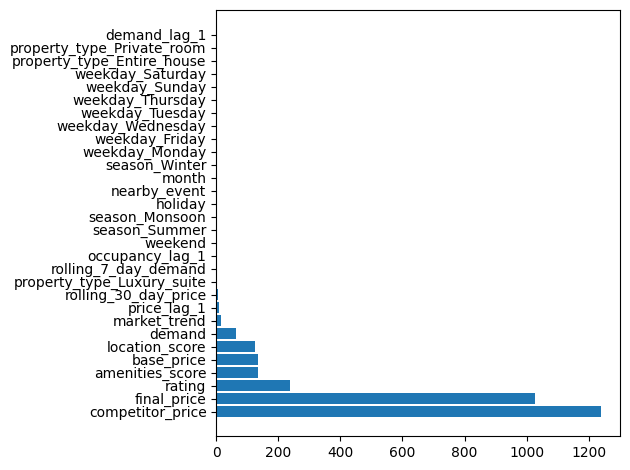

In [13]:
plt.barh(importance_df['feature'],importance_df['importance'])
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import pandas as pd

def predict_prices_batch(model, test_dataset: pd.DataFrame, max_price_steps=50):
    N = len(test_dataset)  
    M = max_price_steps    
    
    df_expanded = test_dataset.loc[test_dataset.index.repeat(M)].copy()
    
    price_increments = np.tile(np.arange(M) * 5, N)
    df_expanded['final_price'] = df_expanded['base_price'] + price_increments
    
    predicted_occupancies = model.predict(df_expanded)
    
    prices_matrix = df_expanded['final_price'].values.reshape(N, M)
    occupancy_matrix = predicted_occupancies.reshape(N, M)
    
    revenue_matrix = prices_matrix * occupancy_matrix
    
    best_indices = np.argmax(revenue_matrix, axis=1)
    best_prices = prices_matrix[np.arange(N), best_indices]
    
    max_revenues = np.max(revenue_matrix, axis=1)
    
    return best_prices.tolist(), max_revenues.tolist()

In [15]:
best_prices, max_optim_revenues = predict_prices_batch(model,X_test)

In [16]:
price_comparison_df = pd.DataFrame({
  'original_prices': X_test['final_price'],
  'original_competitor_prices': X_test['competitor_price'],
  'original_revenue': test_dataset['revenue'],
  'optimised_revenue_calculated': max_optim_revenues,
  'model_optimised_prices': best_prices
})
price_comparison_df.to_csv('../optimizations/optimized_prices.csv')

In [17]:
test_dataset['optimized_revenue'] = max_optim_revenues
original_monthly_revenue = (
  test_dataset
  .groupby(test_dataset['date'].dt.month)['revenue']
  .mean() 
)

optimised_monthly_revenue = (
  test_dataset
  .groupby(test_dataset['date'].dt.month)['optimized_revenue']
  .mean()
)

comparison_df = pd.DataFrame({
    'Original Revenue': original_monthly_revenue,
    'Optimized Revenue': optimised_monthly_revenue
})

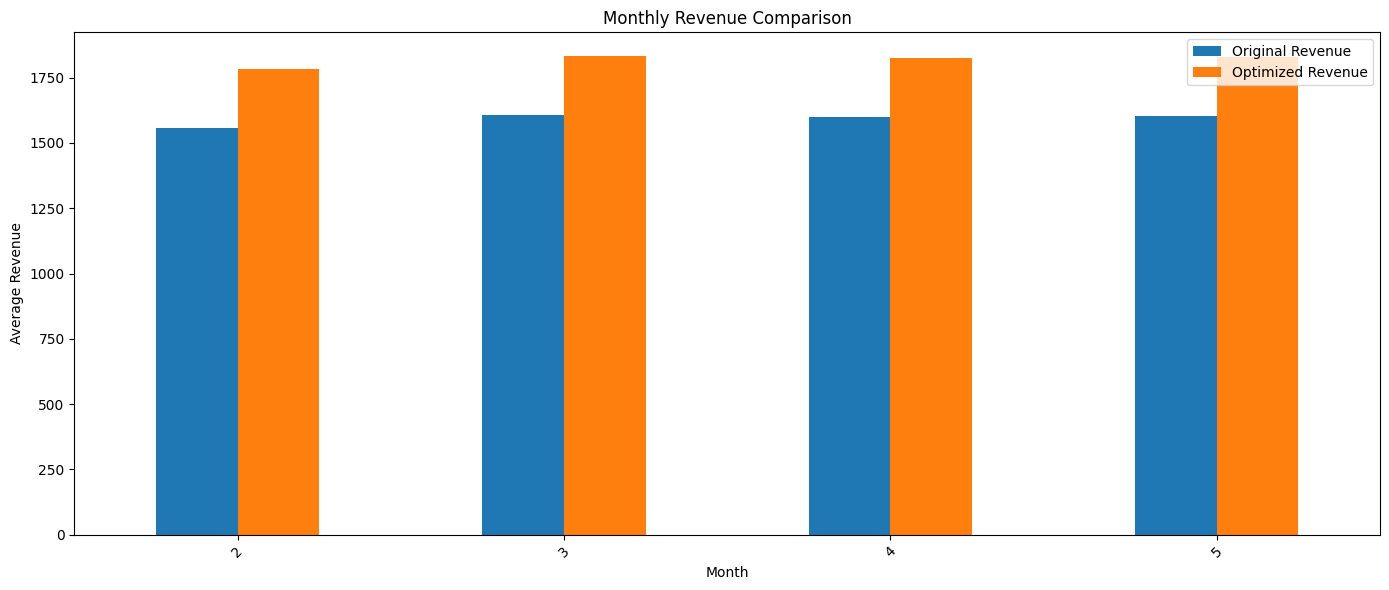

In [18]:
comparison_df.plot(
    kind='bar',
    figsize=(14,6)
)

plt.title(
    'Monthly Revenue Comparison'
)

plt.ylabel('Average Revenue')

plt.xlabel('Month')

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

In [19]:
price_comparison_df.describe()

,original_prices,original_competitor_prices,original_revenue,optimised_revenue_calculated,model_optimised_prices
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,2401.697060,2408.891900,1591.858388,1817.526584,2138.133260
std,840.513406,859.668690,836.608441,706.243166,827.789443
min,1042.410000,846.967501,10.516300,163.628156,1007.500000
25%,1511.080000,1524.839548,974.998075,1155.948698,1238.570000
50%,2429.340000,2427.268738,1411.503200,1859.667121,2174.290000
75%,3356.737500,3257.254085,2206.551325,2233.303205,3148.930000
max,3896.370000,4277.025947,3691.412600,3151.384602,3374.640000


In [21]:
import joblib

joblib.dump(
  model,
  "../models/lightgbm_dynamic_pricing.pkl"
)

['../models/lightgbm_dynamic_pricing.pkl']